In [40]:
import math

import matplotlib.pyplot as plt
import numpy as np

import ansys.motorcad.core as pymotorcad

from tools.motorCAD.pyMCAD import get_stress_data, temperature_adjusted_curve

# 
one of the most important parameters in the rotor design is the length-to-diameter aspect ratio(i.o L/D). A rotor with a low aspect ratio has high

# Utility functions to check non-linear material data

In [ ]:
# Utility functions moved to tool.motorCAD.pyMCAD.stress

# Classes to store and manipulate stress and FEA data

In [ ]:
# Stress parsing + correction classes moved to tool.motorCAD.pyMCAD.stress
# - StressElement / StressRegion / StressRegions
# - get_stress_data()


#  Main script, using the classes and methods defined above


In [41]:
mc = pymotorcad.MotorCAD(open_new_instance=False)

In [42]:
# filePath=r"E:\KDH\KJS\251114_C67_test_Moa_copy2.mot"
# filePath=r"D:\KDHe10\e10_20251226\e10_User.mot"
mc.set_variable("MessageDisplayState", 2)
# mc.load_from_file(filePath)
mc.set_variable("ShaftSpeed", 15000)


In [43]:
mc.do_mechanical_calculation()
stress_regions = get_stress_data(mc)


In [44]:
region_names_to_postprocess = ["Rotor"]


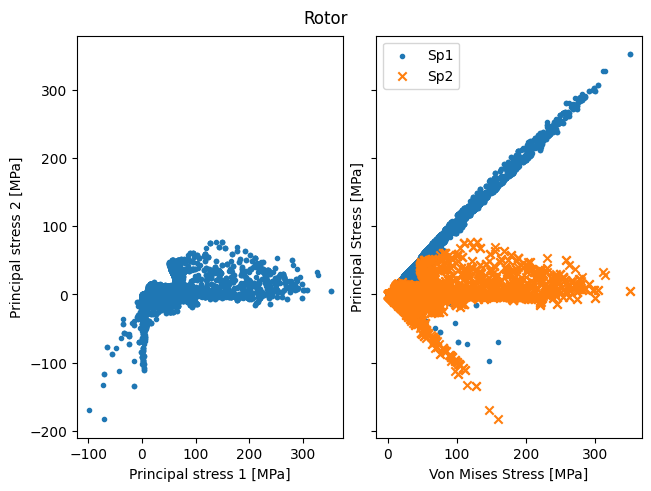

In [45]:
for region_name_to_postprocess in region_names_to_postprocess:
    # Find matching regions
    for i in range(len(stress_regions)):
        if stress_regions[i].region_name == region_name_to_postprocess:
            if stress_regions[i].get_number_elements() > 0:
                fig, ax = plt.subplots(1, 2, layout="constrained", sharey=True)
                ax[0].scatter(
                    stress_regions[i].get_sp1(), stress_regions[i].get_sp2(), marker="."
                )  # , c=svm)
                ax[0].set_xlabel("Principal stress 1 [MPa]")
                ax[0].set_ylabel("Principal stress 2 [MPa]")
                ax[1].scatter(
                    stress_regions[i].get_svm(), stress_regions[i].get_sp1(), marker="."
                )  # , c=svm)
                ax[1].scatter(
                    stress_regions[i].get_svm(), stress_regions[i].get_sp2(), marker="x"
                )  # , c=svm)
                ax[1].legend(["Sp1", "Sp2"])
                ax[1].set_xlabel("Von Mises Stress [MPa]")
                ax[1].set_ylabel("Principal Stress [MPa]")
                plt.suptitle(stress_regions[i].region_name)
                plt.show()

# Nonlinear stress-strain(SN) data

In [ ]:
non_linear_strain = np.array(
    [
        0,
        0.0002,
        0.0004,
        0.0006,
        0.0008,
        0.001,
        0.0012,
        0.0014,
        0.0016,
        0.0018,
        0.002,
        0.0022,
        0.0024,
        0.0026,
        0.0028,
        0.003,
        0.0032,
        0.0034,
        0.0036,
        0.0038,
        0.004,
        0.0042,
        0.0044,
        0.0046,
        0.0048,
        0.005,
        0.0052,
        0.0054,
        0.0056,
        0.0058,
    ]
)
non_linear_stress = np.array(
    [
        0.0,
        38.5,
        77.0,
        115.5,
        154.1,
        192.5,
        231.0,
        269.5,
        308.0,
        346.5,
        385.0,
        423.5,
        462.1,
        500.6,
        520.3,
        541.1,
        561.8,
        582.6,
        593.7,
        604.8,
        615.9,
        626.9,
        632.0,
        637.1,
        642.1,
        647.2,
        652.2,
        657.3,
        662.3,
        667.4,
    ]
)

In [ ]:
# Check the initial Young's modulus from the data
initial_youngs_modulus_calculated = (non_linear_stress[1] - non_linear_stress[0]) / (
    non_linear_strain[1] - non_linear_strain[0]
)
print(f"Calculated initial Young's modulus: {initial_youngs_modulus_calculated:,.0f} MPa")

# MotorCAD data shows 185 GPa = 185,000 MPa
target_youngs_modulus = 185_000.0  # MPa

# Calculate scaling factor
scaling_factor = target_youngs_modulus / initial_youngs_modulus_calculated
print(f"Scaling factor: {scaling_factor:.6f}")

# Find the divergence point (where plastic deformation starts)
# Typically around yield stress
divergence_idx = None
for i in range(1, len(non_linear_stress)):
    elastic_modulus = non_linear_stress[i] / non_linear_strain[i]
    if not math.isclose(elastic_modulus, initial_youngs_modulus_calculated, rel_tol=0.001):
        divergence_idx = i
        break

if divergence_idx is None:
    divergence_idx = len(non_linear_stress)

print(f"Divergence point at index {divergence_idx}, stress = {non_linear_stress[divergence_idx-1]:.1f} MPa")

# Create adjusted stress-strain curve
non_linear_stress_adjusted = non_linear_stress.copy()

# Scale the elastic region
non_linear_stress_adjusted[:divergence_idx] = non_linear_stress[:divergence_idx] * scaling_factor

# For plastic region, apply a smooth transition
# Scale plastic portion slightly less to maintain curve shape
for i in range(divergence_idx, len(non_linear_stress)):
    # Transition from full scaling to minimal scaling
    weight = 1.0 - (i - divergence_idx) / (len(non_linear_stress) - divergence_idx) * 0.5
    plastic_scaling = scaling_factor * weight + (1.0 - weight)
    non_linear_stress_adjusted[i] = non_linear_stress[i] * plastic_scaling

# Verify the new initial slope
new_initial_slope = (non_linear_stress_adjusted[1] - non_linear_stress_adjusted[0]) / (
    non_linear_strain[1] - non_linear_strain[0]
)
print(f"New initial Young's modulus: {new_initial_slope:,.0f} MPa")

# Plot comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(non_linear_strain, non_linear_stress, 'b-o', label='Original (E=192.5 GPa)', markersize=4)
plt.plot(non_linear_strain, non_linear_stress_adjusted, 'r-s', label='Adjusted (E=185 GPa)', markersize=4)
plt.xlabel("Strain [-]")
plt.ylabel("Stress [MPa]")
plt.title("Stress-Strain Curve Comparison")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(non_linear_strain[:10], non_linear_stress[:10], 'b-o', label='Original', markersize=6)
plt.plot(non_linear_strain[:10], non_linear_stress_adjusted[:10], 'r-s', label='Adjusted', markersize=6)
plt.xlabel("Strain [-]")
plt.ylabel("Stress [MPa]")
plt.title("Elastic Region Detail")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Update the non_linear_stress with the adjusted values
non_linear_stress = non_linear_stress_adjusted.copy()
print("\nStress-strain data has been updated to match MotorCAD Young's modulus of 185 GPa")

In [46]:
# temperature_adjusted_curve() moved to tool.motorCAD.pyMCAD.stress

reference_youngs_modulus = 192_500.0  # MPa at baseline temperature
temperature_offset = 100.0  # deg C above the reference condition

non_linear_stress_15C, youngs_modulus_15C = temperature_adjusted_curve(
    non_linear_strain,
    non_linear_stress,
    reference_youngs_modulus,
    temperature_offset,
 )

print(f"Young's modulus at +{temperature_offset:.0f}°C: {youngs_modulus_15C:,.1f} MPa")

Young's modulus at +100°C: 185,762.5 MPa


In [ ]:
plt.figure()
plt.plot(non_linear_strain, non_linear_stress, label="Reference curve")
plt.plot(non_linear_strain, non_linear_stress_15C, label="Reference +100°C")
plt.xlabel("Strain [-]")
plt.ylabel("Stress [MPa]")
plt.legend()
plt.grid(True)
plt.show()

[(<Figure size 640x480 with 6 Axes>,
  array([<Axes: title={'center': 'Von Mises [MPa]'}>,
         <Axes: title={'center': 'Principal stress 1 [MPa]'}>,
         <Axes: title={'center': 'Principal stress 2 [MPa]'}>], dtype=object))]

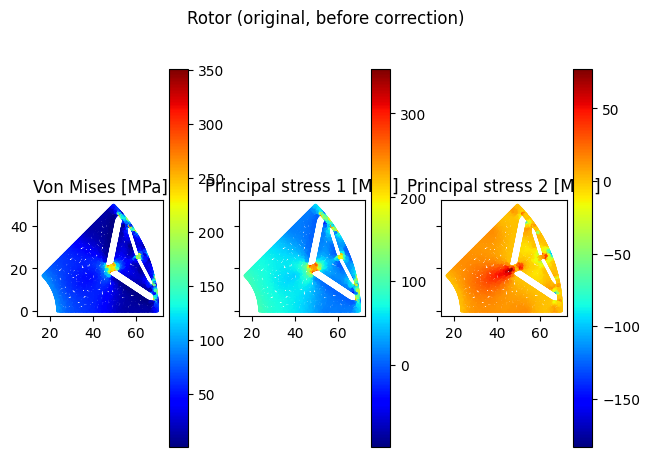

In [47]:
# Plot original (uncorrected) mesh-wise stresses BEFORE applying correction
import importlib

import tools.motorCAD.pyMCAD.stress as stress
importlib.reload(stress)  # pick up local edits without restarting kernel

stress.plot_mesh_stress_fields(
    stress_regions,
    region_names=region_names_to_postprocess,
    fields=("svm", "sp1", "sp2"),
    title_suffix="(original, before correction)",
)

# Apply Correction

In [ ]:
for region_name_to_postprocess in region_names_to_postprocess:
    # Find matching regions
    for i in range(len(stress_regions)):
        if stress_regions[i].region_name == region_name_to_postprocess:
            # Apply the actual stress correction here
            stress_regions[i].apply_corrections(non_linear_strain, non_linear_stress)

            # Print the maximum stresses and strains
            print(f"For region {stress_regions[i].region_name}:")
            print(f"Maximum elastic stress " f"{np.max(stress_regions[i].get_svm()):.6} MPa")
            print(
                f"Maximum stress with Neuber correction: "
                f"{np.max(stress_regions[i].get_stress_nonlinear_neuber()):.6} MPa"
            )
            print(
                f"Maximum stress with Glinka correction: "
                f"{np.max(stress_regions[i].get_stress_nonlinear_glinka()):.6} MPa"
            )
            print(
                f"Maximum plastic strain with Neuber correction: "
                f"{np.max(stress_regions[i].get_strain_plastic_neuber()):.6}"
            )
            print(
                f"Maximum plastic strain with Glinka correction: "
                f"{np.max(stress_regions[i].get_strain_plastic_glinka()):.6}"
            )

            # Plot:
            fig, ax = plt.subplots(3, 1, layout="constrained")

            # Stress vs strain
            ax[0].scatter(
                stress_regions[i].get_strain_nonlinear_neuber(),
                stress_regions[i].get_stress_nonlinear_neuber(),
                marker=".",
            )
            ax[0].scatter(
                stress_regions[i].get_strain_nonlinear_glinka(),
                stress_regions[i].get_stress_nonlinear_glinka(),
                marker="x",
            )
            ax[0].legend(["Neuber", "Glinka"])
            ax[0].set_xlabel("Strain [-]")
            ax[0].set_ylabel("Stress [MPa]")
            # Plastic stress vs elastic stress
            ax[1].scatter(
                stress_regions[i].get_svm(),
                stress_regions[i].get_stress_nonlinear_neuber(),
                marker=".",
            )
            ax[1].scatter(
                stress_regions[i].get_svm(),
                stress_regions[i].get_stress_nonlinear_glinka(),
                marker="x",
            )
            ax[1].legend(["Neuber", "Glinka"])
            ax[1].set_xlabel("Stress Von Mises [MPa]")
            ax[1].set_ylabel("Stress Adjusted [MPa]")
            # Plastic strain vs elastic stress
            ax[2].scatter(
                stress_regions[i].get_svm(),
                stress_regions[i].get_strain_plastic_neuber(),
                marker=".",
            )
            ax[2].scatter(
                stress_regions[i].get_svm(),
                stress_regions[i].get_strain_plastic_glinka(),
                marker="x",
            )
            ax[2].legend(["Neuber", "Glinka"])
            ax[2].set_xlabel("Stress Von Mises [MPa]")
            ax[2].set_ylabel("Plastic strain [-]")
            plt.suptitle(stress_regions[i].region_name)
            plt.show()

            # Plot stress including correction, and plastic strain
            # Plot against element data X and Y (check exactly what this corresponds to,
            # assume element centre, but seems to be one node of triangle)
            cm = plt.colormaps["jet"]
            fig, ax = plt.subplots(2, 2, layout="constrained")
            plot1 = ax[0, 0].scatter(
                stress_regions[i].get_x(),
                stress_regions[i].get_y(),
                c=stress_regions[i].get_stress_nonlinear_neuber(),
                marker=".",
                cmap=cm,
            )
            plt.colorbar(plot1, ax=ax[0, 0])
            ax[0, 0].set_title("Stress (Neuber correction)")

            plot2 = ax[0, 1].scatter(
                stress_regions[i].get_x(),
                stress_regions[i].get_y(),
                c=stress_regions[i].get_stress_nonlinear_glinka(),
                marker=".",
                cmap=cm,
            )
            plt.colorbar(plot2, ax=ax[0, 1])
            ax[0, 1].set_title("Stress (Glinka correction)")

            plot3 = ax[1, 0].scatter(
                stress_regions[i].get_x(),
                stress_regions[i].get_y(),
                c=stress_regions[i].get_strain_plastic_neuber(),
                marker=".",
                cmap=cm,
            )
            plt.colorbar(plot3, ax=ax[1, 0])
            ax[1, 0].set_title("Plastic strain (Neuber correction)")

            plot4 = ax[1, 1].scatter(
                stress_regions[i].get_x(),
                stress_regions[i].get_y(),
                c=stress_regions[i].get_strain_plastic_glinka(),
                marker=".",
                cmap=cm,
            )
            plt.colorbar(plot4, ax=ax[1, 1])
            ax[1, 1].set_title("Plastic strain (Glinka correction)")
            plt.show()